In [1]:
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize
import seaborn as sns
import networkx as nx   
mpl.rcParams['figure.dpi'] = 300
import subprocess
import pandas as pd
import numpy as np
from skimage.io import imread
from skimage import filters
from skimage.feature import match_template
from networkx.drawing.nx_pydot import graphviz_layout
import scipy as sp
import itertools
from scipy.signal import savgol_filter


plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

%matplotlib inline

In [2]:
import pandas as pd
from io import StringIO
from pathlib import Path


def extract_channel_df(txt_path: str, channel_header: str) -> pd.DataFrame:
    """
    Return a DataFrame for the data block beginning with channel_header.
    • Reads file with latin-1 encoding (avoids Unicode errors).
    • Drops padding rows (Temp == 0.0).
    • Converts Time → Timedelta and all remaining columns → float.
    """
    # Load whole file safely
    lines = Path(txt_path).read_text(encoding="latin1").splitlines()

    # Locate the block header
    header_i = next(i for i, ln in enumerate(lines) if ln.strip() == channel_header)

    # Start after any blank spacer lines following the header
    start = header_i + 1
    while start < len(lines) and not lines[start].strip():
        start += 1

    # Collect table lines until blank, a new header, or a zero-row sentinel
    block = []
    for ln in lines[start:]:
        if not ln.strip() or ln.startswith("oxoplate_channel_trf"):
            break
        block.append(ln)
        if ln.startswith("0:00:00\t0.0"):
            break

    # Build DataFrame
    df = pd.read_csv(StringIO("\n".join(block)), sep="\t", engine="python")

    # Remove trailing rows where temperature column is 0.0
    temp_col = df.columns[1]
    df = df[df[temp_col] != 0.0].reset_index(drop=True)

    # Type conversions
    df["Time"] = pd.to_timedelta(df["Time"])
    numeric_cols = df.columns.difference(["Time"])
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="raise")

    return df


file_path = "eDCS031_Chloramphenicol_OCR_Final.txt"

# Extract DataFrames
df_540_590 = extract_channel_df(file_path, "oxoplate_channel_trf:540,590")
df_540_640 = extract_channel_df(file_path, "oxoplate_channel_trf:540,650")  # 650 nm in file

# Quick confirmation of dtypes
print(df_540_590.dtypes)
print(df_540_640.dtypes)


Time                               timedelta64[ns]
T° oxoplate_channel_trf:540,590            float64
B2                                         float64
B3                                         float64
B4                                         float64
C2                                         float64
C3                                         float64
C4                                         float64
D2                                         float64
D3                                         float64
D4                                         float64
E2                                         float64
E3                                         float64
E4                                         float64
E5                                         float64
E6                                         float64
E7                                         float64
E8                                         float64
E9                                         float64
E10                            

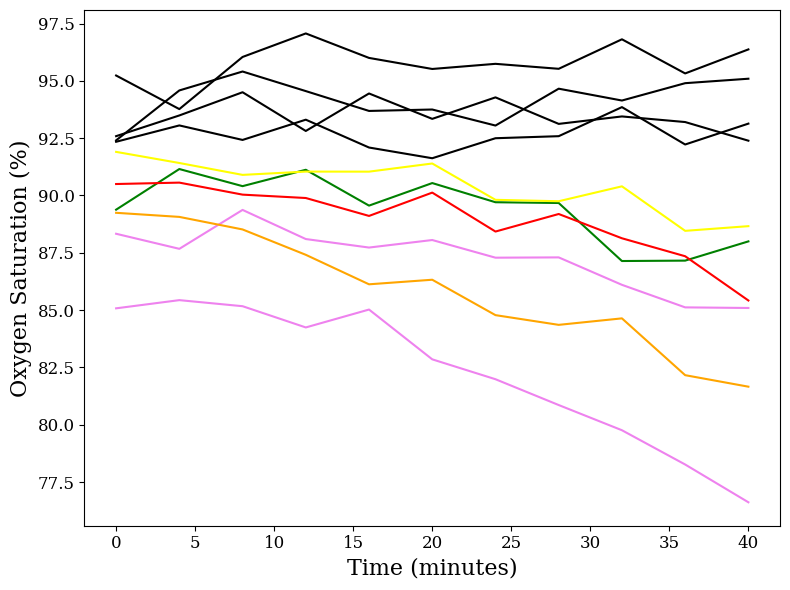

In [3]:
ir = df_540_640.iloc[:, 2:] / df_540_590.iloc[:, 2:]
ir.columns
k0 = ir.loc[:, ['B2', 'C2', 'D2']].mean(axis=0).mean()
k100 = ir.loc[:, ['B3', 'C3', 'D3']].mean(axis=0).mean()
k100
k0
data = ir.loc[:, :]
data.shape
po2 = 100 * ((k0 / data) - 1) / ((k0 / k100) - 1)
po2.shape

s = 0
e = 10

plt.rc('font',family='serif')
plt.figure(figsize=(8, 6))
plt.grid(False)
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E2'], color='violet')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E3'], color='violet')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E4'], color='green')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E5'], color='yellow')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E6'], color='orange')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E7'], color='red')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E8'], color='black')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E9'], color='black')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E10'], color='black')
plt.plot(np.arange(s, e + 1, 1) * 4, po2.loc[:, 'E11'], color='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Time (minutes)', fontsize=16)
plt.ylabel('Oxygen Saturation (%)', fontsize=16)
plt.tight_layout()

In [4]:
def ocr_fit(x,qmax,c):
    return -(qmax*x)+c

def fit_ocr(x,y):
    popt1,pcov=sp.optimize.curve_fit(ocr_fit,x,y*2.83,method='trf')
    return popt1[0]

In [5]:
ocr=[]
s=2
e=10

prefixes=['E','F','G']
nums=range(2,12,1)

ids=[f"{p}{n}" for p,n in itertools.product(prefixes,nums)]

for r in ids:
    ocr.append(fit_ocr(np.arange(s,e+1,1)*4,po2.loc[s:e,r]))

In [6]:
od600=np.array(pd.read_csv('od600_chloramphenicol_final.csv',header=None))
od600_corrected=od600[1:,:]-od600[0,0:3].mean()

In [7]:
ocr_arr=np.array(ocr).reshape(3,10)/od600_corrected
ocr_arr.shape

(3, 10)

In [8]:
ocr_mean=ocr_arr.mean(axis=0)
ocr_mean

array([61.19605778, 62.03987458, 46.1698539 , 49.55130305, 23.2863961 ,
       14.51117375, -0.75903224, -1.80860114,  1.10888605, -4.32087544])

In [9]:
ocr_std=ocr_arr.std(axis=0)/np.sqrt(3)
ocr_std

array([ 7.42322573, 10.79962167,  5.97623754,  3.9075565 ,  1.51111793,
        2.047257  ,  0.88836899,  2.04346362,  2.07562677,  0.772026  ])

In [10]:
concs=np.array([0,31.25,62.5,125,250,300,400,500,1000,2000])


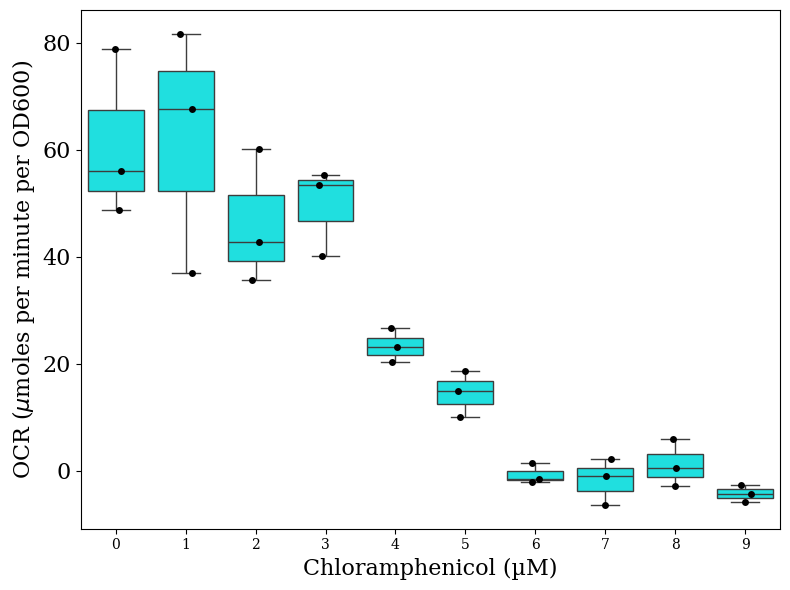

In [11]:
plt.figure(figsize=(8, 6))
plt.grid(False)
sns.boxplot(data=ocr_arr[:,:],color='cyan')
sns.stripplot(data=ocr_arr[:,:],color='black')
# plt.xticks(np.arange(0,10,1),concs,fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Chloramphenicol (µM)', fontsize=16)
plt.ylabel(r'OCR ($\mu$moles per minute per OD600)', fontsize=16)
# plt.text(2,10,r"$OCR=11.04.\frac{[CHL]^{2.85}}{[CHL]^{2.85}+58^{2.85}}$",fontsize=24)
# plt.xscale('log',base=2)
plt.tight_layout()


In [12]:
def hill_func(x,beta0,beta,k,n):
    return beta0+(beta*(k**n)/((k**n)+(x**n)))

In [13]:
subs=[0,1,3,4,5,7,8,9]
ocr_subset=ocr_mean.round(0)[subs]
conc_subset=concs[subs]

In [14]:
popt,pcov=sp.optimize.curve_fit(hill_func,conc_subset,ocr_subset,p0=[0,50,250,3],method='trf')


In [15]:
from scipy.stats import t

perr = np.sqrt(np.diag(pcov))
alpha = 0.05  # 95% confidence interval
n = len(conc_subset)           # number of data points
p = len(popt)            # number of parameters
dof = max(0, n - p)      # degrees of freedom
tval = t.ppf(1.0 - alpha/2., dof)

for param, sigma in zip(popt, perr):
    print(f"{param:.5f} ± {tval*sigma:.5f}")

-3.05933 ± 5.26332
64.33496 ± 7.87227
216.31640 ± 33.59661
3.05124 ± 1.28009


In [16]:
rand_chl_conc=np.arange(0,2000,100)

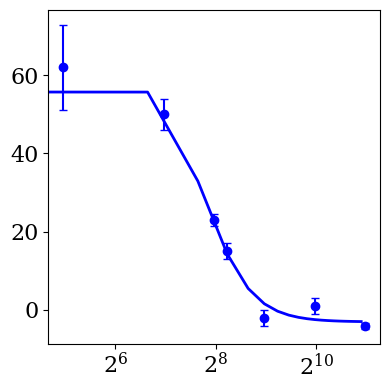

In [17]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)

ax.errorbar(
    conc_subset, ocr_subset,
    yerr=ocr_std[subs],
    fmt="o", color="b", capsize=3, ms=6
)
ax.plot(
    rand_chl_conc,
    hill_func(rand_chl_conc, *popt),
    color="b", linestyle="-", lw=2
)

ax.set_xscale('log', base=2)

# larger tick labels on both axes
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
fig.savefig("ocr_ultrasensitivity.svg", dpi=1200)


In [28]:
popt

array([ -3.05933497,  64.3349559 , 216.31640343,   3.05123792])

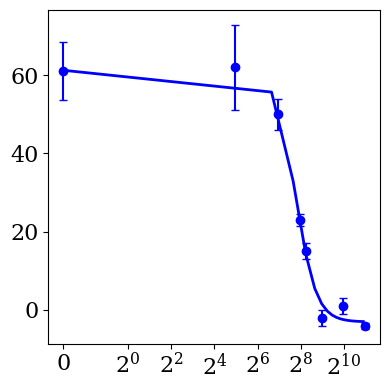

In [18]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)

ax.errorbar(
    conc_subset, ocr_subset,
    yerr=ocr_std[subs],
    fmt="o", color="b", capsize=3, ms=6
)
ax.plot(
    rand_chl_conc,
    hill_func(rand_chl_conc, *popt),
    color="b", linestyle="-", lw=2
)

ax.set_xscale('symlog', linthresh=0.5, linscale=1, base=2)

# 1) Only powers of 2 as major ticks (no 1.5, 3, etc.)
loc = mticker.SymmetricalLogLocator(base=2, linthresh=0.5, subs=[1.0])
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_minor_locator(mticker.NullLocator())

# 2) Make them sparser by dropping every other tick (still powers of 2)
labels = ax.get_xticks()
# e.g. keep every second tick:
keep = labels[::2]
ax.set_xticks(keep)

ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
fig.savefig("ocr_ultrasensitivity_symlog_sparse.png", dpi=1200)

In [19]:
x_data = conc_subset
y_data = ocr_subset
y_fit  = hill_func(x_data, *popt)
resid  = y_data - y_fit
sigma  = resid.std(ddof=1)

n_boot = 10000
n_boot_vals = []

for _ in range(n_boot):
    y_boot = y_fit + np.random.normal(0, sigma, size=y_data.size)
    popt_b, _ = sp.optimize.curve_fit(
        hill_func, x_data, y_boot,
        p0=popt, method='trf'
    )
    n_boot_vals.append(popt_b[3])

n_boot_vals = np.array(n_boot_vals)


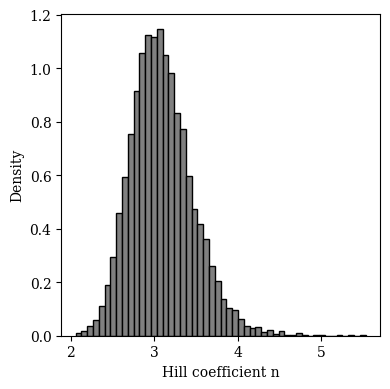

In [20]:
plt.figure(figsize=(4,4))
plt.hist(n_boot_vals, bins=50, color='gray', edgecolor='k', density=True)
plt.xlabel("Hill coefficient n")
plt.ylabel("Density")
plt.tight_layout()

/tmp/ipykernel_3984691/4228029293.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


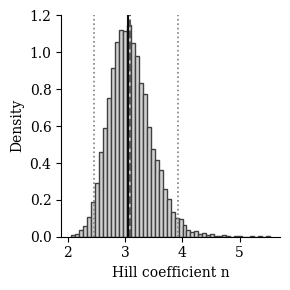

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


mean_val = np.mean(n_boot_vals)
median_val = np.median(n_boot_vals)
ci_low, ci_high = np.percentile(n_boot_vals, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(3, 3),constrained_layout=True)

ax.hist(
    n_boot_vals,
    bins=50,
    color='0.82',
    edgecolor='0.25',
    density=True
)

# mean = medium gray dashed
ax.axvline(mean_val, color='0.35', linestyle='--', linewidth=1.5)

# median = dark solid
ax.axvline(median_val, color='0.05', linestyle='-', linewidth=1.5)

# 95% CI = light dotted
ax.axvline(ci_low, color='0.5', linestyle=':', linewidth=1.2)
ax.axvline(ci_high, color='0.5', linestyle=':', linewidth=1.2)

# ax.text(
#     0.98, 0.95,
#     f"mean = {mean_val:.2f}\nmedian = {median_val:.2f}\n95% CI [{ci_low:.2f}, {ci_high:.2f}]",
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=8
# )

ax.set_xlabel('Hill coefficient n')
ax.set_ylabel('Density')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it
plt.tight_layout()
plt.savefig("Hill_coeff_distribution.svg", format="svg")

In [22]:
# bootstrap 95% CI for Hill coefficient n
ci_low, ci_high = np.percentile(n_boot_vals, [2.5, 97.5])
n_median = np.median(n_boot_vals)

print(f"n (median) = {n_median:.3f}")
print(f"95% CI (bootstrap) = [{ci_low:.3f}, {ci_high:.3f}]")


n (median) = 3.059
95% CI (bootstrap) = [2.458, 3.917]


In [27]:
# bootstrap 95% CI for Hill coefficient n
ci_low, ci_high = np.percentile(n_boot_vals, [2.5, 97.5])
n_median = np.mean(n_boot_vals)

print(f"n (median) = {n_median:.3f}")
print(f"95% CI (bootstrap) = [{ci_low:.3f}, {ci_high:.3f}]")


n (median) = 3.092
95% CI (bootstrap) = [2.458, 3.917]


In [23]:
n0 = 3.0
# two-sided bootstrap p-value
p_boot = np.mean(np.abs(n_boot_vals - n0) >= np.abs(n_median - n0))
print("bootstrap p-value vs n = 3:", p_boot)


bootstrap p-value vs n = 3: 0.8661


In [24]:
from scipy.stats import t

n_hat = popt[3]
se_n  = perr[3]
n0    = 3.0          # hypothesized value

t_stat = (n_hat - n0) / se_n
dof    = len(conc_subset) - len(popt)
p_val  = 2 * (1 - t.cdf(abs(t_stat), dof))

print("t =", t_stat, "df =", dof, "p =", p_val)


t = 0.11113253488822554 df = 4 p = 0.9168643645623895


/tmp/ipykernel_3984691/2104922655.py:10: RuntimeWarning: invalid value encountered in power
  return beta0 + beta * (c**n) / (kc**n + c**n)
/tmp/ipykernel_3984691/2104922655.py:10: RuntimeWarning: invalid value encountered in scalar power
  return beta0 + beta * (c**n) / (kc**n + c**n)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


Fitted parameters (with cmax):
beta0 = -2.8115821243778707
beta  = 64.34071223679362
kc    = 1.357026894429506 (in c-space)
n     = 3.6700057496104965
cmax  = 8.730619886374868


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

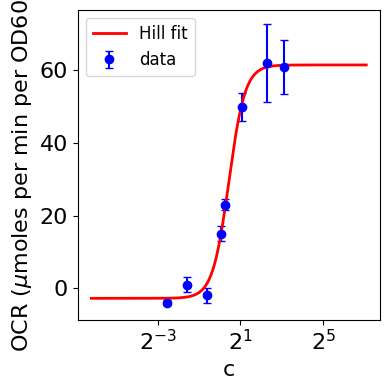

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- 1. Define Hill function with cmax inside ----------
# conc: original chloramphenicol concentration
def hill_with_cmax(conc, beta0, beta, kc, n, cmax):
    # intermediate variable c(conc)
    c = cmax * 40**1. / (conc**1. + 40**1.)
    return beta0 + beta * (c**n) / (kc**n + c**n)

# ---------- 2. Fit OCR vs conc with intermediate c ----------
# initial guesses
p0 = [
    np.min(ocr_subset),                               # beta0 ~ baseline
    np.max(ocr_subset) - np.min(ocr_subset),          # beta ~ amplitude
    np.median(40**1. / (conc_subset**1. + 40**1.)),               # kc in c-space, rough guess
    3.0,                                              # n ~ moderate Hill
    1.0                                               # cmax initial
]

popt_cmax, pcov_cmax = curve_fit(
    hill_with_cmax,
    conc_subset,
    ocr_subset,
    p0=p0,
    method="trf",
)

beta0_fit, beta_fit, kc_fit, n_fit, cmax_fit = popt_cmax

print("Fitted parameters (with cmax):")
print("beta0 =", beta0_fit)
print("beta  =", beta_fit)
print("kc    =", kc_fit, "(in c-space)")
print("n     =", n_fit)
print("cmax  =", cmax_fit)

# ---------- 3. Recompute c from fitted cmax for plotting ----------
c = cmax_fit * 40 / (conc_subset + 40)

# wide c-grid around kc in c-space
c_grid = np.logspace(
    np.log10(kc_fit) - 2,
    np.log10(kc_fit) + 2,
    400
)
ocr_fit = beta0_fit + beta_fit * (c_grid**n_fit) / (kc_fit**n_fit + c_grid**n_fit)

# ---------- 4. Plot data (in c) and Hill curve ----------
fig, ax = plt.subplots(figsize=(4, 4))

ax.errorbar(
    c,
    ocr_subset,
    yerr=ocr_std[subs],
    fmt="o",
    color="b",
    capsize=3,
    ms=6,
    label="data",
)

ax.plot(
    c_grid,
    ocr_fit,
    color="r",
    lw=2,
    label="Hill fit",
)

ax.set_xscale("log", base=2)
ax.set_xlabel("c", fontsize=16)
ax.set_ylabel(r"OCR ($\mu$moles per min per OD600)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=16)
ax.legend(fontsize=12)
plt.tight_layout()


In [26]:
from scipy.optimize import curve_fit

# --- 1. Fitted curve and residuals in c-space ---
y_data = ocr_subset
y_fit  = hill_c(c, *popt_c)
resid  = y_data - y_fit
sigma  = resid.std(ddof=1)

# --- 2. Robust bootstrap for n in c-space ---
n_boot = 1000
n_boot_vals_c = []

# reasonable bounds to prevent blow-up
# beta0 in [min(y)-|amp|, max(y)+|amp|], beta in [0, 10*|amp|], kc>0, n in [0.1, 20]
ymin, ymax = y_data.min(), y_data.max()
amp = ymax - ymin
bounds_lower = [ymin - amp, 0.0, 1e-6, 0.1]
bounds_upper = [ymax + amp, 10*amp, 10*np.max(c), 20.0]

for _ in range(n_boot):
    y_boot = y_fit + np.random.normal(0, sigma, size=y_data.size)

    try:
        popt_b, _ = curve_fit(
            hill_c,
            c,
            y_boot,
            p0=popt_c,
            bounds=(bounds_lower, bounds_upper),
            method="trf",
            max_nfev=5000,   # increase a bit but finite
        )
        n_boot_vals_c.append(popt_b[3])  # Hill exponent n
    except RuntimeError:
        # skip this bootstrap sample if the fit fails
        continue

n_boot_vals_c = np.array(n_boot_vals_c)

# median and 95% CI
n_med_c = np.median(n_boot_vals_c)
ci_lo_c, ci_hi_c = np.percentile(n_boot_vals_c, [2.5, 97.5])

print("Hill n (c-space), median =", n_med_c)
print("95% CI =", ci_lo_c, ci_hi_c)


NameError: name 'hill_c' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.hist(n_boot_vals_c, bins=40, density=True, color="gray", edgecolor="k")
plt.axvline(n_med_c, color="r", lw=2, label=f"median = {n_med_c:.2f}")
plt.axvline(ci_lo_c, color="b", lw=1, linestyle="--", label=f"2.5% = {ci_lo_c:.2f}")
plt.axvline(ci_hi_c, color="b", lw=1, linestyle="--", label=f"97.5% = {ci_hi_c:.2f}")
plt.xlabel("Hill exponent n (c-space)")
plt.ylabel("Density")
plt.legend(fontsize=10)
plt.tight_layout()
